# **Pipeline**
### (*from raw image to defect creation/annihilation*)

In [197]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
import os
import sys
from pathlib import Path
import trackpy as tp
import statsmodels.api as sm
import pandas as pd
from scipy.stats import circmean, circstd
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

In [2]:
# defect detection params
ori_sigma = 11

# trajectory params
search_range = 35
memory = 3

# pair papams
dist_threshold = 15

# Load and Save params
# image_path = r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos18"
image_path = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Pos6"
output_csv = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Nematics\output_Hacat.csv"
input_csv = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Nematics\PlusAndMinusTM.csv"

In [207]:
# image_path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\real ccw\2"
# image_path = r"C:\Users\victo\OneDrive - BGU\BEER\6"
# image_path = r"C:\Users\victo\OneDrive - BGU\BEER\B-sub-sur-minus-in-supernatant-40X-100fps"
image_path = r"D:\C2C12 and RPE in 6 well\15min5x\_1\Pos28"
image_list = glob.glob(os.path.join(image_path, '*.tif'))
image_list = natsorted(image_list, key=lambda y: y.lower())

In [67]:
%matplotlib qt
# check flow_sigma and ori_sigma
plot_flow_and_nematics(
    image_list, 120, flow_sigma=15, ori_sigma=15, 
    #    box=[500,500,800,900], 
    bg=True,
    )

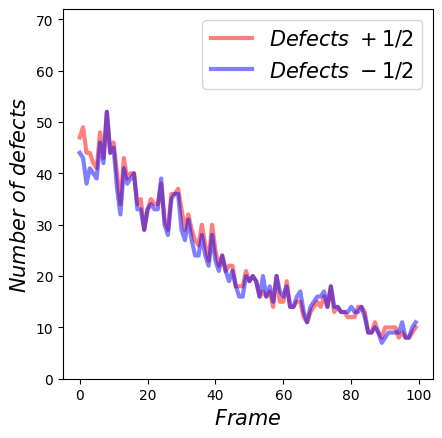

In [208]:
%matplotlib inline
# check image to list result
df_plus, df_minus = image_list_to_defect_list(image_list[0:100], sigma=21)
df_plus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="r", label="$Defects ~+1/2$")
df_minus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="b", label="$Defects ~-1/2$")

plt.xlabel("$Frame$", fontsize=15)
plt.ylabel("$Number ~of ~defects$", fontsize=15)
plt.ylim(0, df_plus.groupby('frame').size().max() + 20)
plt.legend(fontsize=15); 
plt.gca().set_box_aspect(1)

In [ ]:
df_list= Parallel(n_jobs=4)(delayed(lambda df: tp.link_df(df, search_range, memory=memory)) (df) for df in [df_plus,df_minus])

In [ ]:
t_all = pd.concat([df_list[0], df_list[1]], ignore_index=True)
t_all.rename(columns={
                    'x':'x_img', 'y':'y_img',
                    'x_ind':'x_img1', 'y_ind':'y_img1',
                    'frame':'FRAME', 'particle':'TRACK_ID',
                    }, inplace=True)
t_all["POSITION_T"] = t_all["FRAME"]
t_all.to_csv(output_csv)

In [ ]:
find_pairs_and_save_to_csv(input_csv, output_csv, dist_threshold=dist_threshold)

all_pairs_df = pd.read_csv(output_csv).dropna(subset=["min_id","creation"])


## One Step: 
### *image list >> pair dataset*

In [ ]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
import os
import sys
from pathlib import Path
import trackpy as tp
import statsmodels.api as sm
import pandas as pd
from scipy.stats import circmean, circstd, circvar
import warnings
import seaborn as sns

# Suppress all warnings
warnings.filterwarnings("ignore")

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

def expand_3fold_angles(df, col_value="angp1_rel", col_condition="angp1_rel"):
    """
    Expand angles in the given column to cover [-2pi, 2pi] for better histogram visualization.
    Returns a numpy array with the expanded angles.
    """
    wrap_angle = 2 * np.pi if col_value == col_condition else 0
    return np.concatenate([
        df[col_value].values,
        df[col_value][df[col_condition] > 0].values - wrap_angle,
        df[col_value][df[col_condition] < 0].values + wrap_angle
    ])

def find_pair_origin(group, xp='xp', yp='yp', xm='xm', ym='ym', dist='track_frame', dist0=20.):
    group = group.sort_values(by=dist)
    position = (group['distance'] - dist0).abs().idxmin()
    x0 = (group[xp].loc[position] + group[xm].loc[position])/2
    y0 = (group[yp].loc[position] + group[ym].loc[position])/2
    gamma0 = np.arctan2(group[ym].loc[position]-group[yp].loc[position],
                         group[xm].loc[position]-group[xp].loc[position]) 

    group["angp_"] = np.arctan2(group[yp]-y0, group[xp]-x0)
    group["angp_"] = (group["angp_"] - group["angp_"].loc[position]) %(2*np.pi)
    group["angp_"][group["angp_"]>np.pi] = group["angp_"][group["angp_"]>np.pi]-2*np.pi

    group["angm_"] = np.arctan2(group[ym]-y0, group[xm]-x0)
    group["angm_"] = ((group["angm_"] - group["angm_"].loc[position]) + np.pi) %(2*np.pi)
    # group["angm_"][group["angm_"]>np.pi] = group["angm_"][group["angm_"]>np.pi] - 2*np.pi

    # defect pair axis relative to fusion/annhilation axis
    group["gamma"] = np.arctan2(group[ym]-group[yp],
                                group[xm]-group[xp]) %(2*np.pi) #- gamma0) 
    
    group["gamma_rel"] = (group["gamma"] - gamma0) % (2*np.pi)
    group["gamma_rel"][group["gamma_rel"]>np.pi] = group["gamma_rel"][group["gamma_rel"]>np.pi] - 2*np.pi

    group["delta"] = (group["angp1"] - 3*group["angm1"] + 2*group["gamma"] - np.pi) %(2*np.pi)
    group["delta"][group["delta"]>np.pi] = group["delta"][group["delta"]>np.pi] - 2*np.pi

    group["angp1_rel"][group["angp1_rel"]>np.pi] = group["angp1_rel"][group["angp1_rel"]>np.pi] - 2*np.pi

    return group

label = 'track_frame'
# label = 'distance'

In [17]:
# # Load and Save params
# # image_path = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Pos9"
# # image_path = r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos16"
# image_path = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\HT1080_5x_5_min_24_well_media_DMSO_C3\_2\Pos41"
# image_path = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_CK666\_1\Pos38"  #Pos30 "#Pos38"
# params = {"ori_sigma": 7, "search_range": 20, "memory": 2, "dist_threshold": 7, "first_image": 60, "last_image": 140, "step": 1}

# image_path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\CheY\6870"
# # params = {"ori_sigma": 11, "search_range": 25, "memory": 3, "dist_threshold": 11, "first_image": 0, "last_image": 500, "step": 1}
# params = {"ori_sigma": 21, "search_range": 35, "memory": 3, "dist_threshold": 21, "first_image": 1315, "last_image": 2000, "step": 1}

# image_path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\CheY\69"
# params = {"ori_sigma": 11, "search_range": 25, "memory": 3, "dist_threshold": 11, "first_image": 2947, "last_image": 3500, "step": 1}
# params = {"ori_sigma": 21, "search_range": 35, "memory": 3, "dist_threshold": 21, "first_image": 0, "last_image": 1000, "step": 1}

# image_path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\CheY\circle"
# params = {"ori_sigma": 15, "search_range": 35, "memory": 3, "dist_threshold": 15, "first_image": 1123, "last_image": 1823, "step": 1}
# params = {"ori_sigma": 7, "search_range": 25, "memory": 3, "dist_threshold": 7, "first_image": 1, "last_image": 500, "step": 1}

# image_path = r"C:\Users\victo\Downloads\tubulin" # https://www.nature.com/articles/s41567-019-0600-y
# params = {"ori_sigma": 25, "search_range": 45, "memory": 1, "dist_threshold": 25, "first_image": 1, "last_image": -1, "step": 2}

# image_path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\real ccw\1"
# params = {"ori_sigma": 11, "search_range": 45, "memory": 3, "dist_threshold": 12, "first_image": 0, "last_image": -1, "step": 1}

image_path = r"C:\Users\victo\OneDrive - BGU\BEER\6"
params = {"ori_sigma": 11, "search_range": 45, "memory": 3, "dist_threshold": 12, "first_image": 0, "last_image": -1, "step": 1}

# # image_path = r"C:\Users\victo\Downloads\ecoli" # https://academic.oup.com/pnasnexus/article/1/5/pgac269/6948003
# # params = {"ori_sigma": 11, "search_range": 35, "memory": 3, "dist_threshold": 10, "first_image": 0, "last_image": -1, "step": 1}

# # image_path = r"C:\Users\victo\Downloads\Myxo" # https://academic.oup.com/pnasnexus/article/1/5/pgac269/6948003
# # params = {"ori_sigma": 5, "search_range": 35, "memory": 3, "dist_threshold": 5, "first_image": 0, "last_image": -1, "step": 1}

# image_path = r"C:\Users\victo\Downloads\Yuv_Numeric\FRAMES_00"  #Pos30 "#Pos38"
# params = {"ori_sigma": 4, "search_range": 15, "memory": 2, "dist_threshold": 4, "first_image": 0, "last_image": -1, "step": 1}

# image_path = r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Raw"
# params = {"ori_sigma": 21, "search_range": 35, "memory": 2, "dist_threshold": 21, "first_image": 160, "last_image": 500, "step": 1}

# dist_thres = params["dist_threshold"]

input_csv = os.path.join(
    os.path.dirname(image_path), "Nematics",
    "PlusAndMinusTM_{}_frame{}_{}_sigma{}_step{}.csv".format(os.path.basename(image_path), params["first_image"],
                                                 params["last_image"],params["ori_sigma"],params["step"])
    )

output_csv = os.path.join(
    os.path.dirname(image_path), "Nematics",
    "output_{}_frame{}_{}_sigma{}_step{}.csv".format(os.path.basename(image_path), params["first_image"],
                                         params["last_image"],params["dist_threshold"],params["step"])
    )

In [18]:
# image_list = glob.glob(os.path.join(image_path, '*.tif')) + glob.glob(os.path.join(image_path, '*.png')) 
# image_list = natsorted(image_list, key=lambda y: y.lower())[params["first_image"]::params["step"]]
# len(image_list[:params["last_image"]]), image_list[:params["last_image"]][0], image_list[:params["last_image"]][-1]

In [19]:
image_list = glob.glob(os.path.join(image_path, '*.tif')) + glob.glob(os.path.join(image_path, '*.png')) 
image_list = natsorted(image_list, key=lambda y: y.lower())[params["first_image"]::params["step"]]
df_plus, df_minus = image_list_to_defect_list(image_list[:params["last_image"]], sigma=params["ori_sigma"])

# image_list = natsorted(glob.glob(os.path.join(image_path, '*.png')), key=lambda y: y.lower())[::params["step"]]
# df_plus, df_minus = image_list_to_defect_list(image_list[params["first_image"]:params["last_image"]], sigma=params["ori_sigma"])

# params["search_range"] = 20
# params["memory"] = 2

df_list= Parallel(n_jobs=4)(delayed(lambda df: tp.link_df(df, params["search_range"], memory=params["memory"])) (df) for df in [df_plus,df_minus])

# join plus and minus dataframes
t_all = pd.concat([df_list[0], df_list[1]], ignore_index=True)
# rename columns to match find_pairs function (Java)
t_all.rename(columns={
                    'x':'x_img', 'y':'y_img',
                    'x_ind':'x_img1', 'y_ind':'y_img1',
                    'frame':'FRAME', 'particle':'TRACK_ID',
                    }, inplace=True)
t_all["POSITION_T"] = t_all["FRAME"]
os.makedirs(os.path.dirname(input_csv), exist_ok=True)
t_all.to_csv(input_csv)

find_pairs_and_save_to_csv(input_csv, output_csv, dist_threshold=params["dist_threshold"])

all_pairs_df = pd.read_csv(output_csv).dropna(subset=["min_id","creation"])

Java program executed successfully.
Output: None
(33431, 27)


(0.0, 290.97088680956136)

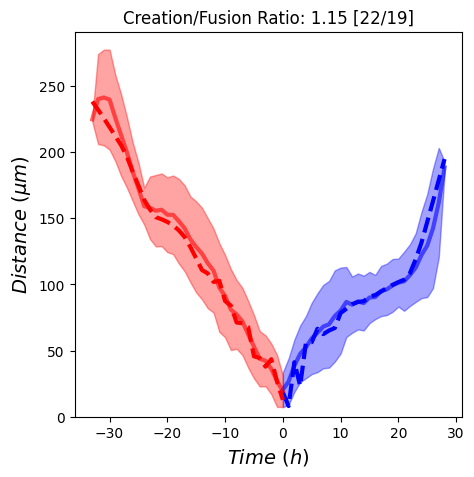

In [51]:
# output_csv = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Nematics\output_Pos9.csv"; dist_thres=11
# output_csv = r"D:\C2C12 and RPE in 6 well\15min5x\_1\Nematics\output_C2C12.csv"; dist_thres=25
# output_csv = r"D:\C2C12 and RPE in 6 well\15min5x\_1\Nematics\output_RPE.csv"; dist_thres=25
# output_csv = r"D:\C2C12 and RPE in 6 well\15min5x\_1\Nematics\output_Pos20.csv"; dist_thres=25
# output_csv = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\HT1080_5x_5_min_24_well_media_DMSO_C3\_2\Nematics\output_Pos41_frame0_200_sigma7.csv"; dist_thres=7
# output_csv = r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_CK666\_1\Nematics\output_Pos3.csv"; dist_thres=7
# output_csv = r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s23456.csv"; dist_thres=15
# output_csv = r"C:\Users\victo\OneDrive - BGU\Dov\output_bacteria6_all.csv"; dist_thres=12
# output_csv = r"C:\Users\victo\Downloads\Nematics\output_ecoli.csv"; dist_thres=10
# output_csv = r"C:\Users\victo\Downloads\Nematics\output_ecoli05.csv"; dist_thres=10
# output_csv = r"C:\Users\victo\Downloads\Nematics\output_tubulin_frame1_-1_sigma15.csv"; dist_thres=15
# output_csv = r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Nematics\output_Raw_frame160_500_sigma21.csv"; dist_thres=21
# output_csv = r"C:\Users\victo\Downloads\Yuv_Numeric\Nematics\output_FRAMES_00_frame0_-1_sigma4.csv"; dist_thres=4  #Pos30 "#Pos38"

output_csv = r"C:\Users\victo\Downloads\Nematics\output_tubulin_frame1_-1_sigma21_step3 - BST.csv"; dist_thres=15
params = {"ori_sigma": 11, "search_range": 35, "memory": 3, "dist_threshold": dist_thres, "first_image": 0, "last_image": -1, "step": 1}


all_pairs_df = pd.read_csv(output_csv).dropna(subset=["min_id","creation"]).dropna(subset=["min_id","creation"])

show = False
win = 1
track_len = 3

all_pairs_df.fuse_up = all_pairs_df.fuse_up.astype("bool")
all_pairs_df_ = all_pairs_df.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()

df_cr = all_pairs_df_[all_pairs_df_.creation].reset_index().copy()
df_cr["track_frame"] = df_cr.groupby(['plus_id','min_id'])['FRAME'].transform(lambda x: x-x.iloc[0])

df_fuse = all_pairs_df_[all_pairs_df_.fusion].reset_index().copy()
df_fuse["track_frame"] = df_fuse.groupby(['plus_id','min_id'])['FRAME'].transform(lambda x: x-x.iloc[-1])

df_all = pd.concat([df_cr, df_fuse])

fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
# for color,df in zip(["b","r","k"], [df_cr, df_fuse, df_all]):
for color,df in zip(["b","r"], [df_cr, df_fuse]):    
    df_ = plot_rolling_average(df, ax1, "distance", "track_frame", win=win, show=~show, color=color, avfunc=np.mean, stdfunc=np.std)
    if not show:
        # ax1.plot(df_.track_frame/12, df_.distance_ave*.74, color, linewidth=3)
        ax1.fill_between(df_.track_frame, 
                        (df_.distance_ave-df_.distance_std), 
                        (df_.distance_ave+df_.distance_std),
                        color=color, alpha=.2)
        # break

    df = df.sort_values('track_frame')
    # Apply LOWESS smoothing
    lowess = sm.nonparametric.lowess
    smoothed = lowess(df['distance'], df['track_frame'], frac=1./11.)  # Adjust frac for smoothing level
    # Create a new DataFrame for the smoothed values
    smoothed_df = pd.DataFrame(smoothed, columns=['track_frame', 'smoothed_distance'])
    ax1.plot(smoothed_df['track_frame'], smoothed_df['smoothed_distance'], "--", color=color, linewidth=3, label='Smoothed Distance')


cr_n = len(all_pairs_df_.plus_id[all_pairs_df_.creation].unique())
fuse_n = len(all_pairs_df_.plus_id[all_pairs_df_.fusion].unique())

plt.title("Creation/Fusion Ratio: %.4s [%.4s/%.4s]" % (cr_n/fuse_n, cr_n, fuse_n))
ax1.set_xlabel("$Time ~(h)$", fontsize=14); ax1.set_ylabel("$Distance ~(\mu m)$", fontsize=14)
# ax1.set_xlim([-70,70]); 
ax1.set_ylim([0,None])
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\distance ecoli.svg")


In [52]:
# label = 'track_frame'
# label = 'distance'

df_fuse = df_fuse.groupby(['plus_id','min_id'], group_keys=False).apply(find_pair_origin, xp='xp', yp='yp', xm='xm', ym='ym', dist=label, dist0=params["dist_threshold"]).reset_index(drop=True)
df_cr = df_cr.groupby(['plus_id','min_id'], group_keys=False).apply(find_pair_origin, xp='xp', yp='yp', xm='xm', ym='ym', dist=label, dist0=params["dist_threshold"]).reset_index(drop=True)

Text(0.5, 0.98, 'output_tubulin_frame1_-1_sigma21_step3 - BST.csv  $~Cr/Fuse: 1.15 ~[22/19]$')

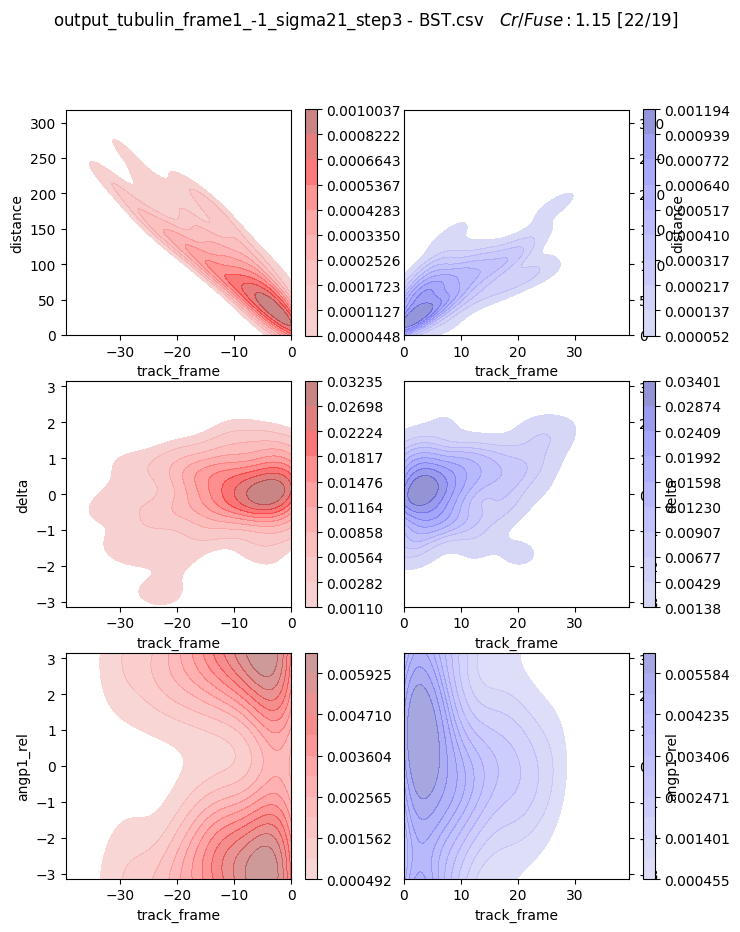

In [53]:
%matplotlib inline

fig, axs = plt.subplots(3, 2, figsize=(8,10))
ax1,ax2,ax3, ax4,ax5,ax6 = axs.ravel()

cbar = True
# track_len = 5
levels = 10
xrange = df_fuse["distance"].median() + 4*df_fuse["distance"].std()
trange = np.abs(df_fuse["track_frame"].median()) + 4*df_fuse["track_frame"].std()

for label, ax_set in zip(["fusion","creation"], [(ax1,ax3,ax5), (ax2,ax4,ax6)]):
    if label == "creation":
        distance_in_time = df_cr.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()
        color = "blue"
    else:
        distance_in_time = df_fuse.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()
        color = "red"

    # Preprocess angles
    distance_in_time.loc[distance_in_time.angp1_rel > np.pi, 'angp1_rel'] -= 2*np.pi
    distance_in_time.loc[distance_in_time.mp_phase > (1/3*np.pi), 'mp_phase'] -= 2/3*np.pi

    # 1. track_frame vs distance
    sns.kdeplot(
        data=distance_in_time, x="track_frame", y="distance",
        ax=ax_set[0], levels=levels, color=color, alpha=0.6, fill=True, cbar=cbar, 
    )
    # 2. track_frame vs delta
    sns.kdeplot(
        data=distance_in_time, x="track_frame", y="delta",
        ax=ax_set[1], levels=levels, color=color, alpha=0.6, fill=True, cbar=cbar
    )
    # 3. 3-fold: track_frame vs angp1_rel
    angp1_rel = expand_3fold_angles(distance_in_time, col_value="angp1_rel", col_condition="angp1_rel")
    track_frame = expand_3fold_angles(distance_in_time, col_value="track_frame", col_condition="angp1_rel")
    df_3fold = pd.DataFrame({"angp1_rel": angp1_rel, "track_frame": track_frame})
    sns.kdeplot(
        data=df_3fold, x="track_frame", y="angp1_rel",
        ax=ax_set[2], levels=int(1.2*levels), color=color, alpha=0.5, fill=True, cbar=cbar
    )

    # Axis settings
    if label == "fusion":
        [ax.set_box_aspect(1) for ax in ax_set]
        [ax.set_xlim([-trange,0]) for ax in ax_set]
        ax_set[0].set_ylim([0,xrange])
    else:
        [(ax.set_box_aspect(1), ax.yaxis.set_label_position("right"), ax.yaxis.tick_right()) for ax in ax_set]
        [ax.set_xlim([0,trange]) for ax in ax_set]
        ax_set[0].set_ylim([0,xrange])

    # ax_set[1].set_ylim([-np.pi, np.pi])
    [ax.set_ylim([-np.pi, np.pi]) for ax in ax_set[1:]]

fig.suptitle("%s  $~Cr/Fuse: %.4s ~[%.4s/%.4s]$" % (os.path.basename(output_csv), cr_n/fuse_n, cr_n, fuse_n), fontsize=12)
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\pair d_delta_phi tubulin_sigma21.svg")


In [54]:
np.arange(0,50,1)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

0     3.162278
1     7.071068
2     8.062258
3     8.544004
4    16.278821
5    17.029386
6    23.600847
7    41.617304
8    64.031242
Name: distance, dtype: float64

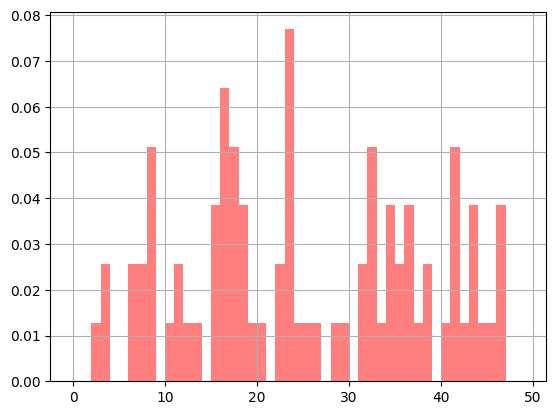

In [55]:
df_fuse.distance.hist(bins=np.arange(0,50,), density=True, alpha=.5, color="r", label="fusion")
df_fuse.distance.mode()

(-3.141592653589793, 3.141592653589793)

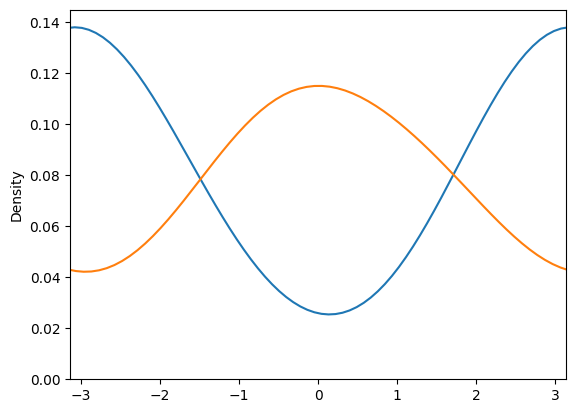

In [56]:
data1 = expand_3fold_angles(df_fuse, col_value="angp1_rel", col_condition="angp1_rel")
ax1 = sns.kdeplot(data1, fill=False)
data2 = expand_3fold_angles(df_cr, col_value="angp1_rel", col_condition="angp1_rel")
ax2 = sns.kdeplot(data2, fill=False)
plt.xlim([-np.pi, np.pi])
# _ = plt.hist(df_fuse.angp1_rel, bins=30, alpha=.6, rwidth=.9, density=True)

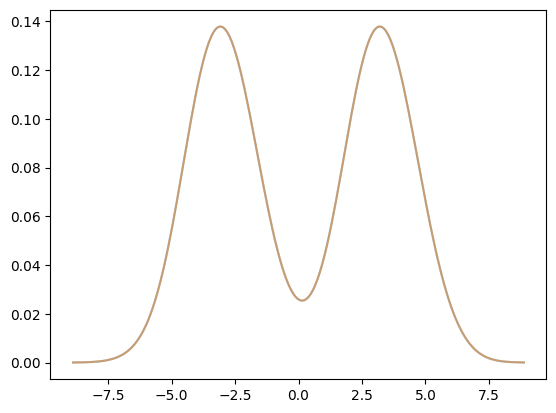

In [57]:
for ax in (ax1, ax2):
    line = ax.get_lines()[0] # Get the first (and usually only) Line2D object
    x, y = line.get_data()
    plt.plot(x, y, alpha=0.5)
# plt.xlim([-np.pi, np.pi])    

(-3.141592653589793, 3.141592653589793)

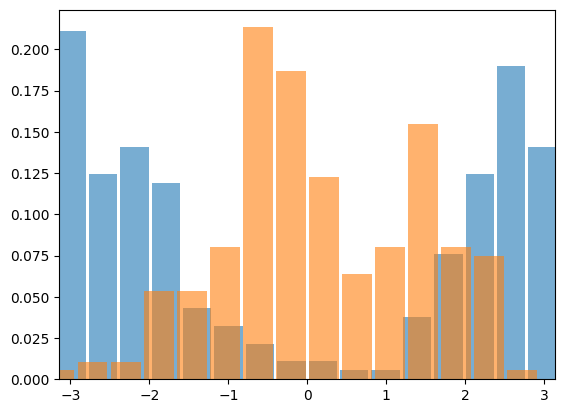

In [58]:
plt.hist(data1, bins=30, alpha=.6, rwidth=.9, density=True)
plt.hist(data2, bins=30, alpha=.6, rwidth=.9, density=True)
plt.xlim([-np.pi, np.pi])

In [59]:
circmean(df_fuse.angp1_rel, low=-np.pi, high=np.pi)*180/np.pi, circstd(np.abs(df_fuse.angp1_rel), low=0, high=np.pi)
# plt.hist(np.abs(df_fuse.angp1_rel), bins=30, alpha=.6, rwidth=.9, density=True)

(np.float64(-174.37708661658945), np.float64(0.5807035840637966))

In [60]:
# circmean(df_fuse["angp1_rel"], low=-np.pi, high=np.pi), circmean(expand_3fold_angles(df_fuse, col_value="angp1_rel", col_condition="angp1_rel"), low=-np.pi, high=np.pi)
# circmean(df_cr["angp1_rel"], low=-np.pi, high=np.pi), circmean(expand_3fold_angles(df_cr, col_value="angp1_rel", col_condition="angp1_rel"), low=-np.pi, high=np.pi)
# circmean(df_cr["angp1_rel"], low=-np.pi, high=np.pi), (circvar(df_cr["angp1_rel"], low=-np.pi, high=np.pi)/len(df_cr))**.5
# circmean(df_fuse["angp1_rel"], low=-np.pi, high=np.pi), (circvar(df_fuse["angp1_rel"], low=-np.pi, high=np.pi)/len(df_cr))**.5

In [61]:
circmean(df_fuse["angp1_rel"], high=2*np.pi, low=0)

np.float64(3.2397310056847615)

In [62]:
"%s  $~Cr/Fuse: %.4s ~[%.4s/%.4s]"\n" e$r" % (os.path.basename(output_csv), cr_n/fuse_n, cr_n, fuse_n)

SyntaxError: unexpected character after line continuation character (1574433110.py, line 1)

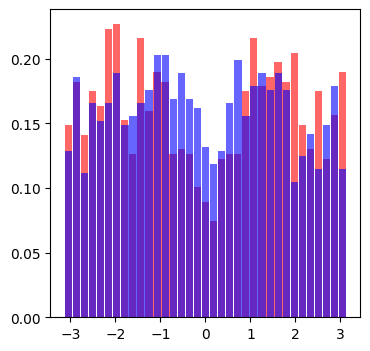

In [ ]:
fig, ax1 = plt.subplots(1,1, figsize=(4, 4))

bins = 35

df_fuse3 = df_fuse[(df_fuse.track_frame>-20) & (df_fuse.track_frame<-3)].copy()
df_cr3 = df_cr[(df_cr.track_frame<20) & (df_cr.track_frame>3)].copy()
# df_ = df_cr[df_cr.track_frame<15].copy()
df_fuse3_phi = expand_3fold_angles(df_fuse3, col_value="angp1_rel", col_condition="angp1_rel")
df_cr3_phi = expand_3fold_angles(df_cr3, col_value="angp1_rel", col_condition="angp1_rel")

_ = ax1.hist(df_fuse.angp1_rel[(df_fuse.track_frame>-10) & (df_fuse.track_frame<-3)], bins=bins, color="red", alpha=.6, label="fusion", rwidth=.9, density=True)
_ = ax1.hist(df_cr.angp1_rel[(df_cr.track_frame<10) & (df_cr.track_frame>3)], bins=bins, color="blue", alpha=.6, label="fusion", rwidth=.9, density=True)

# _ = ax1.hist(df_fuse3_phi, bins=bins, color="red", alpha=.6, label="fusion", rwidth=.9, density=True)
# _ = ax1.hist(df_cr3_phi, bins=bins, color="blue", alpha=.6, label="fusion", rwidth=.9, density=True)



157.88348703129154
157.64451371375097


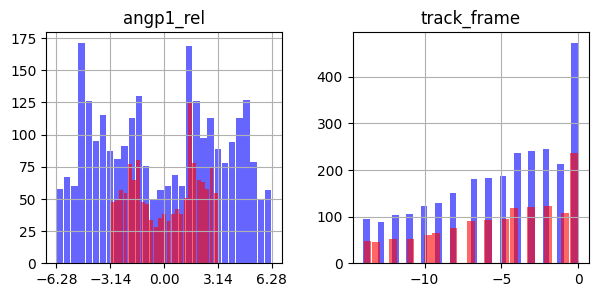

In [ ]:
%matplotlib inline
df_ = df_fuse[df_fuse.track_frame>-15].copy()
# df_ = df_cr[df_cr.track_frame<15].copy()
angp1_rel = expand_3fold_angles(df_, col_value="angp1_rel", col_condition="angp1_rel")
track_frame = expand_3fold_angles(df_, col_value="track_frame", col_condition="angp1_rel")

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(7, 3))
ax1.hist(angp1_rel, bins=30, color="blue", alpha=.6, label="fusion", rwidth=.9)
df_.hist(bins=25, column="angp1_rel", color="red", alpha=.6, label="fusion", rwidth=.9, ax=ax1)
ax1.set_xticks(np.arange(-2*np.pi, 2*np.pi+.1, np.pi))

ax2.hist(track_frame, bins=30, color="blue", alpha=.6, label="fusion", rwidth=.9)
df_.hist(bins=25, column="track_frame", color="red", alpha=.6, label="fusion", rwidth=.9, ax=ax2)

print(circmean(angp1_rel)*180/np.pi)
print(circmean(df_["angp1_rel"])*180/np.pi)

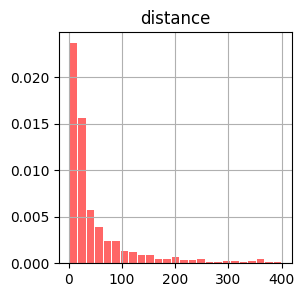

In [ ]:
# df_fuse1 = df_cr.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()
# df_fuse1[df_fuse1.track_frame<35].hist(bins=25, column="angp1_rel", color="red", alpha=.6, label="fusion",rwidth=.9)
label = "distance"
fig, ax = plt.subplots(1,1, figsize=(3, 3))
# all_pairs_df.hist(bins=25, column=label, color="green", alpha=.6, label="fusion",rwidth=.9, ax=ax, density=True)
p = df_fuse.hist(bins=25, column=label, color="red", alpha=.6, label="fusion",rwidth=.9, ax=ax, density=True)
# df_cr.hist(bins=25, column=label, color="blue", alpha=.6, label="fusion",rwidth=.9, ax=ax, density=True)

# # Draw horizontal lines at the medians of the two distributions
# ax.vlines(
#    np.abs(df_fuse[label].median()) + 2*df_fuse[label].std(),
#     0, .03,#ax.get_xlim()[1],
#     colors="black", linewidth=3, linestyles="--"
#     )

In [ ]:
all_pairs_df = all_pairs_df.groupby(['plus_id','min_id'], group_keys=False).apply(find_pair_origin, xp='xp', yp='yp', xm='xm', ym='ym', dist=label, dist0=params["dist_threshold"]).reset_index(drop=True)

all_pairs_df.angp1_rel.min(), all_pairs_df.angp1_rel.max()

(np.float64(-3.1340013645521303), np.float64(3.141592653589793))

(-3.141592653589793, 3.141592653589793)

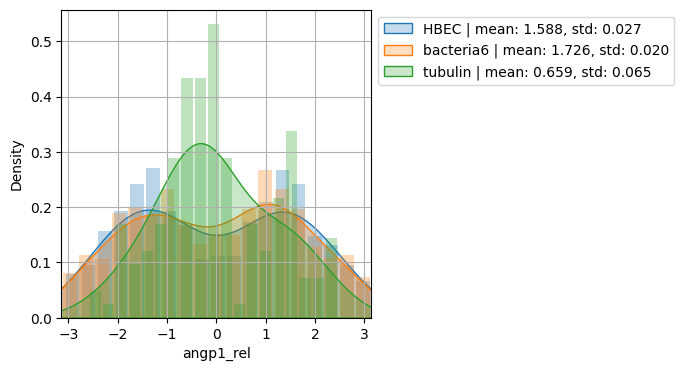

In [ ]:
output_csvs = [
    # r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Nematics\output_Pos9.csv",
    # r"D:\C2C12 and RPE in 6 well\15min5x\_1\Nematics\output_C2C12.csv",
    # r"E:\C2C12 and RPE in 6 well\15min5x\_1\Nematics\output_RPE.csv",
    # r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\HT1080_5x_5_min_24_well_media_DMSO_C3\_2\Nematics\output_Pos41_frame0_200_sigma7.csv",
    # r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6Wells_5X_15min_CK666\_1\Nematics\output_Pos3.csv",
    r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s23456.csv",
    r"C:\Users\victo\OneDrive - BGU\Dov\output_bacteria6_all.csv",
    # r"C:\Users\victo\OneDrive - BGU\BEER\Nematics\output_6_frame0_-1_sigma12_step1.csv",
    # r"C:\Users\victo\OneDrive - BGU\BEER\Nematics\output_6_frame0_-1_sigma15_step1.csv",
    # r"C:\Users\victo\Downloads\Nematics\output_ecoli.csv",
    # r"C:\Users\victo\Downloads\Nematics\output_ecoli05.csv",
    r"C:\Users\victo\Downloads\Nematics\output_tubulin_frame1_-1_sigma21_step3 - BST.csv", #+
    # r"C:\Users\victo\Downloads\Nematics\output_tubulin_frame1_-1_sigma25_step2.csv", #+
    # r"C:\Users\victo\Downloads\Nematics\output_tubulin_frame1_-1_sigma25_step2.csv",
    # r"C:\Users\victo\Downloads\Nematics\output_tubulin.csv",
    # r"C:\Users\victo\OneDrive - BGU\HBEC\s2(120-1057)\Nematics\output_Raw_frame160_500_sigma21.csv",
    # r"C:\Users\victo\Downloads\Yuv_Numeric\Nematics\output_FRAMES_00_frame0_-1_sigma4.csv"
]

means = []
stds = []
labels = []
track_len = 3

FUSION = False

# fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6, 4))
fig, ax1 = plt.subplots(1,1, figsize=(4, 4))
for d, sigma, output_csv in zip([.7,.7,3.,3], [21, 12, 21], output_csvs):
    all_pairs_df = pd.read_csv(output_csv).dropna(subset=["min_id","creation"]).dropna(subset=["min_id","creation"])
    all_pairs_df.fuse_up = all_pairs_df.fuse_up.astype("bool")
    all_pairs_df_ = all_pairs_df.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()

    process_type = "fusion" if FUSION else "creation"
    low, high = (0, np.pi) if FUSION else (-np.pi, 0)

    df = all_pairs_df_[all_pairs_df_[process_type]].reset_index().copy()
    
    if FUSION:
        df["track_frame"] = df.groupby(['plus_id','min_id'])['FRAME'].transform(lambda x: x-x.iloc[-1])
    else:
        df["track_frame"] = df.groupby(['plus_id','min_id'])['FRAME'].transform(lambda x: x-x.iloc[0])

    df = df.groupby(['plus_id','min_id'], group_keys=False).apply(find_pair_origin, xp='xp', yp='yp', xm='xm', ym='ym', dist=label, dist0=sigma).reset_index(drop=True)
    dist = d*df.distance.median()

    if FUSION:
        df.loc[df.angp1_rel < 0, 'angp1_rel'] += 2*np.pi
        # df.loc[df.angp1_rel < 0, 'angp1_rel'] *= -1.

    # plt.hist(df.angp1_rel, bins=35, alpha=.6, rwidth=.9, density=True, label=os.path.basename(output_csv).split("_")[1])

    # data1 = expand_3fold_angles(df, col_value="angp1_rel", col_condition="angp1_rel")
    time_condition = ((df.track_frame>-20) & (df.track_frame<2))if FUSION else ((df.track_frame<25) & (df.track_frame>2))
    data = df.angp1_rel[(time_condition & (df.distance<dist))] #[(df.distance<dist)]#

    fname = os.path.basename(output_csv).split("_")[1]
    res = "mean: %.5s, std: %.5s" %(np.abs(circmean(data, low=low, high=high)),  circvar(data, low=low, high=high)/len(data)**.5)

    data.hist(bins=19, alpha=.3, rwidth=.85, density=True)   #for FUSION bins=16
    ax1 = sns.kdeplot(data, 
                      bw_adjust=1.6, fill=True, #alpha=.8,
                      label=fname + " | " + res
                      )
    means.append(data)
          

plt.legend(loc='upper left', fontsize=10, bbox_to_anchor=(1, 1))
plt.xlim([0, 2*np.pi]) if FUSION else plt.xlim([-np.pi, np.pi])
# plt.xlim([0, np.pi])

# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\cr_all.svg")


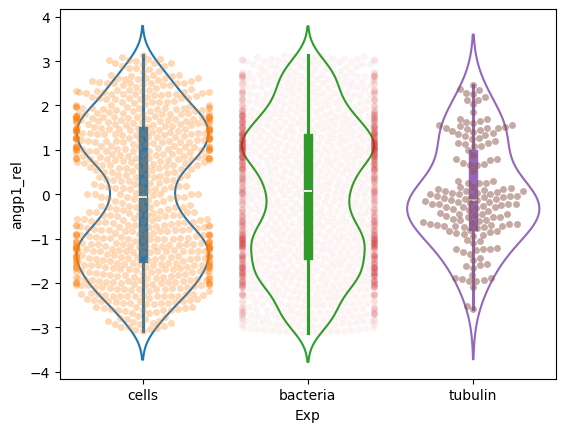

In [ ]:
# fig, axs = plt.subplots(3,1)
# for name,bw,alpha,m, ax in zip(['cells','bacteria','tubulin'], [.2,.2,.5],[.3,.05,.5], means, axs):

fig, ax = plt.subplots(1,1)#, figsize=(4,4))
for name,bw,alpha,m in zip(['cells','bacteria','tubulin'], [.2,.2,.5],[.3,.05,.5], means):    

    m = m.reset_index()
    m['Exp'] = name
    sns.violinplot(data=m, x='Exp', y='angp1_rel', bw=bw, fill=False, inner="box", ax=ax) #, color="0.9", fill=False,  bw=bw, alpha=.6)#, split=True
    # sns.stripplot(x='Exp', y='angp1_rel', data=m, jitter=True, zorder=1, alpha=.3, ax=ax)
    sns.swarmplot(x='Exp', y='angp1_rel', data=m, alpha=alpha,  marker="o", ax=ax)

# plt.ylim([0, 2*np.pi]) if FUSION else plt.ylim([-np.pi, np.pi])   
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\fuse_all_violinplot.svg")

In [ ]:
t

NameError: name 't' is not defined

<Axes: >

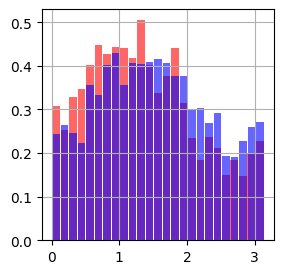

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(3, 3))
df_cr["angp1_rel"].abs().hist(ax=ax, bins=25,  color="red", alpha=.6, label="fusion",rwidth=.9, density=True)
df_fuse["angp1_rel"].abs().hist(ax=ax, bins=25, color="blue", alpha=.6, label="fusion",rwidth=.9, density=True)

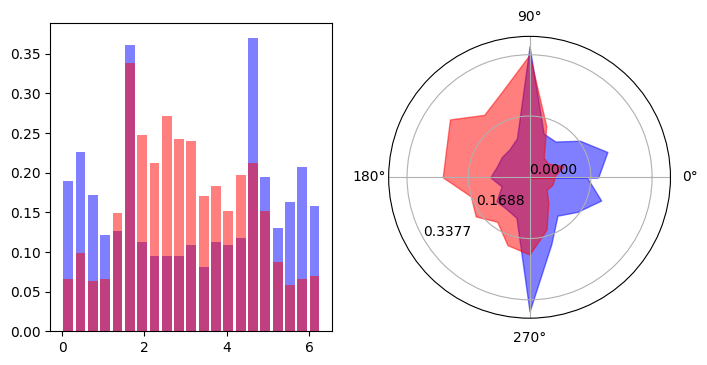

In [ ]:
%matplotlib inline
dist = all_pairs_df.distance.median() + 2*all_pairs_df.distance.std()
# track_len = 3
bins_number = 21  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi
bins_ = np.linspace(0, 2*np.pi, bins_number)
width =  1.9*np.pi / bins_number

# df_all = plus_minus_df[plus_minus_df.fuse_up & plus_minus_df.creation].copy()

df_fuse1 = df_fuse.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()
df_cr1 = df_cr.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()

df_all = [
          # expand_3fold_angles(df_cr1, col_value="angp1_rel", col_condition="angp1_rel"),#
          # expand_3fold_angles(df_fuse1, col_value="angp1_rel", col_condition="angp1_rel")#
          df_cr1.angp1_rel[df_cr1.distance<dist].copy() % (2*np.pi),          
          df_fuse1.angp1_rel[df_fuse1.distance<dist].copy() % (2*np.pi)
          ]
# df_all = [
#           df_fuse1.angp1_rel[(df_fuse1.fuse_up) & (df_fuse1.distance<dist)].copy() % (2*np.pi),     
#           df_fuse1.angp1_rel[(~df_fuse1.fuse_up) & (df_fuse1.distance<dist)].copy() % (2*np.pi),
#           ]
# df_all = [
#           df_cr1.angp1_rel[(df_cr1.fuse_up) & (df_cr1.distance<dist)].copy() % (2*np.pi),
#           df_cr1.angp1_rel[(~df_cr1.fuse_up) & (df_cr1.distance<dist)].copy() % (2*np.pi),
#           ]

fig = plt.figure(figsize=(8,4))
ax1 = plt.subplot(121); ax2 = plt.subplot(122, projection='polar')

for color, y in zip(["b","r"], df_all):
    p,_,_ = ax1.hist(y, bins, alpha=.5, density=True, rwidth=.8, color=color)
    # p,_,_ = ax1.hist(y*180/np.pi, bins=60, alpha=.5, density=True, rwidth=.8, color=color)
    # ax2.bar(bins_, p, color=color, width=width, bottom=0., alpha=.6)
    ax2.fill_between(bins_, p, color=color, alpha=.5)
    ax2.set_rgrids(np.linspace(0, p.max(),3), angle=210); ax2.set_thetagrids([0,90,180,270])

# ax1.set_xlim([-180, 180])
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\bacteria pdef fuse create.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\HBEC pdef fuse create.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\bacteria plus create.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\HBEC plus fuse.svg")

Text(0.5, 1.0, 'dist>80.51')

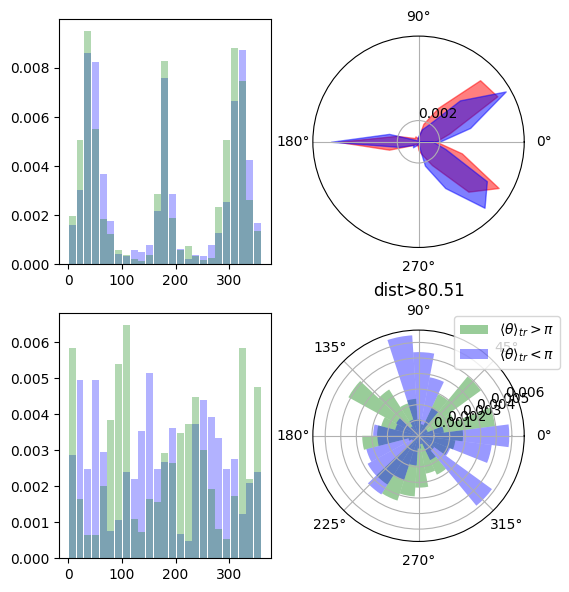

In [ ]:
%matplotlib inline
df_all = df_cr1.copy()
# df_all = df_fuse1.copy()
# df_all = df_all.groupby('plus_id').filter(lambda x: len(x)>10).copy()
# dist = 40

bins_number = 25  # the [0, 360) interval will be subdivided into this
# number of equal bins
bins = np.linspace(0, 2*np.pi, bins_number+1)
bins_ = np.linspace(0, 2*np.pi, bins_number)
width = 2 * np.pi / bins_number

m_ang = []
m_ang_up_close, m_ang_down_close = [], []
m_ang_up_far, m_ang_down_far = [], []
for i in range(3):
    m_ang.append(df_all["angm"+str(i+1)+"_rel"][df_all["distance"]<dist].values)   

    m_ang_up_close.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        df_all["fuse_up"], df_all["distance"]<dist)].values)
    m_ang_down_close.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        ~df_all["fuse_up"], df_all["distance"]<dist)].values)
    m_ang_up_far.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        df_all["fuse_up"], df_all["distance"]>dist)].values)
    m_ang_down_far.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        ~df_all["fuse_up"], df_all["distance"]>dist)].values)
    # break

m_ang = np.concatenate(m_ang)     
m_ang_up_close = np.concatenate(m_ang_up_close) 
m_ang_down_close = np.concatenate(m_ang_down_close) 
m_ang_up_far = np.concatenate(m_ang_up_far) 
m_ang_down_far = np.concatenate(m_ang_down_far) 

fig1 = plt.figure(figsize=(6,7))
ax1 = plt.subplot(221)
ax2 = plt.subplot(222, projection='polar')
ax3 = plt.subplot(223)
ax4 = plt.subplot(224, projection='polar')

# p1,_,_ = ax1.hist((m_ang_up_close % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
# p1,_,_ = ax1.hist((m_ang % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
#                     density=True, rwidth=.9, alpha=.3, color="b")
p1,_,_ = ax1.hist((m_ang_up_close % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="b")

# p2,_,_ = ax1.hist(360-(-m_ang_down_close % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p2,_,_ = ax1.hist((m_ang_down_close % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="g")

ax2.fill_between(bins_, p1, color="r", alpha=.5)
ax2.fill_between(bins_, p2, color="b", alpha=.5)
ax2.set_rgrids(np.arange(.002,.005,.003), angle=90); ax2.set_thetagrids([0,90,180,270])
# ax2.bar(bins[:bins_number], p1, color="green", width=width, bottom=0.0, alpha=.4,
#                     label=r"$\langle \theta \rangle _{tr} > \pi$")
# ax2.bar(bins[:bins_number], p2, color="blue", width=width, bottom=0.0, alpha=.4,
#                     label=r"$\langle \theta \rangle _{tr} < \pi$")
# ax2.legend(bbox_to_anchor=(1.2, 1.1)); ax2.set_title("dist<%s" % dist)

# p3,_,_ = ax3.hist((m_ang_up_far % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p3,_,_ = ax3.hist((m_ang_up_far % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="b")

# p4,_,_ = ax3.hist(360-(-m_ang_down_far % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p4,_,_ = ax3.hist(m_ang_down_far % (2*np.pi)*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="g")

ax4.bar(bins[:bins_number], p3, color="green", width=width, bottom=0.0, alpha=.4,
                    label=r"$\langle \theta \rangle _{tr} > \pi$")
ax4.bar(bins[:bins_number], p4, color="blue", width=width, bottom=0.0, alpha=.4,
                    label=r"$\langle \theta \rangle _{tr} < \pi$")
ax4.legend(bbox_to_anchor=(1.2, 1.1)); ax4.set_title("dist>%.5s" % dist)

# fig1.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\HBEC_minus_hist_cr.svg")


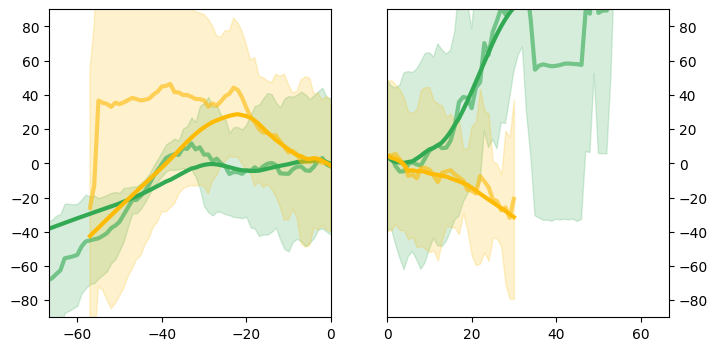

In [ ]:
%matplotlib inline

fig, axs = plt.subplots(1, 2, figsize=(8,4))
ylabel = "gamma_rel"#"delta"#'distance'#"delta" #"angp1_rel"# #"gamma"#"angp_"#"gamma"#"gamma_rel"
xlabel = 'track_frame'#'distance'#
levels = 10

dfs = [df_fuse[df_fuse.fuse_up], df_fuse[~df_fuse.fuse_up], df_cr[df_cr.fuse_up],df_cr[~df_cr.fuse_up]]
axs_ = [axs[0],axs[0],axs[1],axs[1]]; colors = ["#32a953","#fdbb05","#32a953","#fdbb05"]

# dfs = [df_fuse, df_cr]
# axs_ = [axs[0],axs[1]]; colors = ["r","b"]

for ax, color, df in zip(axs_, 
                         colors, 
                         dfs):
    
    df = df.sort_values(xlabel)
    if len(dfs)>1:
        # Apply LOWESS smoothing
        lowess = sm.nonparametric.lowess
        smoothedp = lowess(df[ylabel], df[xlabel], frac=1./3.)  # Adjust frac for smoothing level
        # Create a new DataFrame for the smoothed values
        smoothed_dfp = pd.DataFrame(smoothedp, columns=[xlabel, 'smoothed_'+ylabel])
        smoothed_dfp['distance'] = df['distance'].values
        ax.plot(smoothed_dfp[xlabel], (smoothed_dfp['smoothed_'+ylabel])*180/np.pi, color=color, linewidth=3, alpha=1.)    

    # sns.kdeplot(data=df, x=xlabel, y=ylabel, ax=ax, levels=levels, alpha=.6, fill=True, color=color)
    win = 1
    plot_rolling_average(df, ax, ylabel, xlabel, win=win, color=color, show=True, std=circstd, low=-np.pi, high=np.pi)


# xlim = 60
# for ax in (axs):
#     ax.set_xlim([-xlim,xlim])
#     # ax.set_xlim([0,100])
#     ax.set_ylim([-np.pi,np.pi])
#     # ax.set_ylim([-180,180])
#     ax.set_box_aspect(1)
#     ax.plot([-xlim,xlim], [0,0], "--k")
#     ax.set_xlabel(label, fontsize=12); ax.set_ylabel(r"$\gamma$", fontsize=12)
axs[1].yaxis.set_label_position("right"),axs[1].yaxis.tick_right()
# lims = [-np.pi/2, np.pi/2]
lims = [-90, 90]
axs[0].set_ylim(lims); axs[1].set_ylim(lims)
# axs[0].set_ylim([0,150]);axs[1].set_ylim([0,150])
axs[0].set_xlim([-trange,0])
axs[1].set_xlim([0,trange])
# axs[0].set_xlim([-40,0])
# axs[1].set_xlim([0,40])

# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\gammaSTD_tubulin.svg")



Text(0.5, 1.0, 'Rate/Number of binding/unbinding events per X frames')

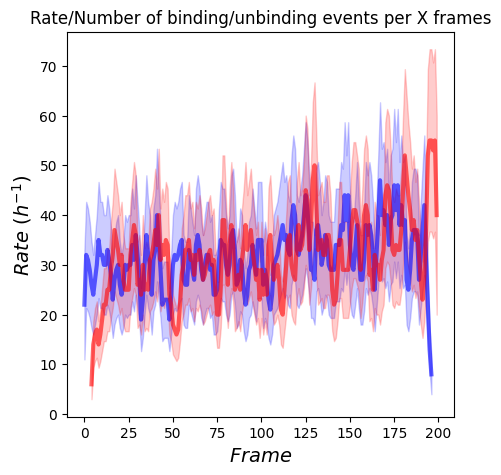

In [ ]:
all_pairs_df.fuse_up = all_pairs_df.fuse_up.astype("bool")
all_pairs_df = all_pairs_df.groupby(['plus_id','min_id']).filter(lambda x: len(x)>3).copy()

first_appearance  = all_pairs_df.groupby(['plus_id','min_id'])['FRAME'].min().reset_index()
last_appearance  = all_pairs_df.groupby(['plus_id','min_id'])['FRAME'].max().reset_index()

fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
for color,appearance in zip(["b","r"], [first_appearance, last_appearance]):
    # Count occurrences of each frame
    frame_counts = appearance['FRAME'].value_counts().sort_index()
    frame_counts_df = frame_counts.reset_index()
    frame_counts_df.columns = ['frame', 'count']

    plot_rolling_average(frame_counts_df, ax1, "count","frame",  win=1, color=color, avfunc=np.sum, stdfunc=np.mean)

plt.xlabel('$Frame$', fontsize=14)
plt.ylabel('$Rate ~(h^{-1})$', fontsize=14)
plt.title("Rate/Number of binding/unbinding events per X frames")    


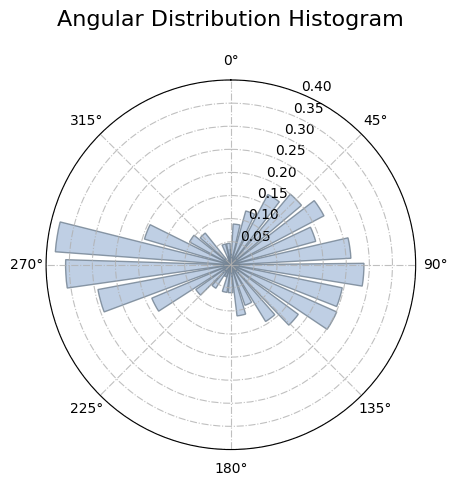

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Simulate angular data (in degrees) with two peaks at 90° and 270°
angles = np.concatenate([
    np.random.normal(loc=90, scale=50, size=500),   # Peak at 90°
    np.random.normal(loc=270, scale=20, size=300),   # Peak at 270°
    np.random.uniform(0, 360, size=200)             # Uniform background
])

# Convert angles to radians for polar plot
radians = np.radians(angles)

# Create figure with polar projection
fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')

# Plot histogram with 36 bins (10° per bin)
hist, bins, _ = ax.hist(
    radians, 
    bins=35, 
    rwidth=0.8,
    color='lightsteelblue',
    edgecolor='slategrey',
    alpha=0.8,
    density=True
)

# Customize plot
ax.set_title("Angular Distribution Histogram", fontsize=16, pad=20)
ax.grid(True, linestyle='-.', alpha=0.8)
ax.set_theta_zero_location('N')  # 0° at the top
ax.set_theta_direction(-1)       # Clockwise direction